In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency


df = pd.read_csv('../../../data/processed/telco_customer_churn_clean.csv')

# วิเคราะห์ นิสัย ของ ประเภท User 

## 1) Senior (กลุ่มผู้สูงอายุ)

### - นิสัย Senior และ ความสอดคล้องต่อ Churn

In [3]:
pd.crosstab(df["SeniorCitizen"], df["Churn"], normalize="index")

Churn,No,Yes
SeniorCitizen,,
0,0.763938,0.236062
1,0.583187,0.416813


In [8]:
table = pd.crosstab(df["SeniorCitizen"], df["Churn"])
chi2, p, dof, expected = chi2_contingency(table)
print(p)

n = table.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(table.shape)-1)))
print(cramers_v)

1.510066805092378e-36
0.15045309974200427


Senior Citizen มีความสัมพันธ์ มีความสัมพันธ์จริง กับ Churn Rate
แต่ความสัมพันธ์อ่อน

### 1.1) ความสอดคล้องต่อ อายุ ต่อช่วง Contract (สัญญาการบริการ)

Churn                               No       Yes
SeniorCitizen Contract                          
0             Month-to-month  0.604302  0.395698
              One year        0.893219  0.106781
              Two year        0.972903  0.027097
1             Month-to-month  0.453532  0.546468
              One year        0.847368  0.152632
              Two year        0.958621  0.041379

จะเห็นว่า เกณฑ์ของ คนที่ยกเลิก จะ เป็นคนสูงอายุ และ การที่ผู้สูงอายุไช้บริการระยะสั้น 

Senior + Short Month-to-Month = Churn rate สูง

In [6]:
table = pd.crosstab(df["Contract"], df["Churn"])
chi2, p, dof, expected = chi2_contingency(table)
print(p)
n = table.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(table.shape)-1)))
print(cramers_v)

5.863038300673391e-258
0.4101156965761409


! Contract มีความสัมพันธ์ มีความสัมพันธ์จริง กับ Churn Rate ความสัมพันธ์ค่อนข้างแรง (medium → strong)

## ความสอดคล้องต่อ อายุ ต่อ ราคาการให้บริการ

In [8]:
pd.crosstab(
    [df["SeniorCitizen"], df["ChargeGroup"]],
    df["Churn"],
    normalize="index"
)

Churn                                No       Yes
SeniorCitizen ChargeGroup                        
0             (18.249, 35.5]   0.896119  0.103881
              (35.5, 70.35]    0.771704  0.228296
              (70.35, 89.85]   0.659389  0.340611
              (89.85, 118.75]  0.694680  0.305320
1             (18.249, 35.5]   0.724138  0.275862
              (35.5, 70.35]    0.625592  0.374408
              (70.35, 89.85]   0.501305  0.498695
              (89.85, 118.75]  0.605206  0.394794

In [9]:
pd.crosstab(
    [df["SeniorCitizen"], df["Contract"], df["ChargeGroup"]],
    df["Churn"],
    normalize="index"
)

Churn                                               No       Yes
SeniorCitizen Contract       ChargeGroup                        
0             Month-to-month (18.249, 35.5]   0.768778  0.231222
                             (35.5, 70.35]    0.660338  0.339662
                             (70.35, 89.85]   0.487150  0.512850
                             (89.85, 118.75]  0.494017  0.505983
              One year       (18.249, 35.5]   0.968000  0.032000
                             (35.5, 70.35]    0.920588  0.079412
                             (70.35, 89.85]   0.886957  0.113043
                             (89.85, 118.75]  0.786982  0.213018
              Two year       (18.249, 35.5]   0.991948  0.008052
                             (35.5, 70.35]    0.977528  0.022472
                             (70.35, 89.85]   0.989583  0.010417
                             (89.85, 118.75]  0.925134  0.074866
1             Month-to-month (18.249, 35.5]   0.454545  0.545455
                             (35.5, 70.35]    0.546584  0.453416
                             (70.35, 89.85]   0.413249  0.586751
                             (89.85, 118.75]  0.445614  0.554386
              One year       (18.249, 35.5]   1.000000  0.000000
                             (35.5, 70.35]    0.838710  0.161290
                             (70.35, 89.85]   0.906250  0.093750
                             (89.85, 118.75]  0.805556  0.194444
              Two year       (18.249, 35.5]   1.000000  0.000000
                             (35.5, 70.35]    0.947368  0.052632
                             (70.35, 89.85]   0.941176  0.058824
                             (89.85, 118.75]  0.955882  0.044118

In [10]:
pd.crosstab(df["Contract"], df["Churn"], normalize="index")

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


<Axes: xlabel='Contract', ylabel='Churn'>

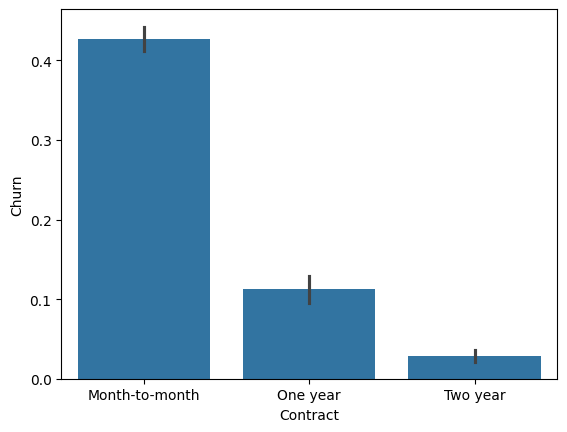

In [12]:
sns.barplot(
    data=df,
    x="Contract",
    y=(df["Churn"]=="Yes").astype(int)
)

In [13]:
table = pd.crosstab(df["Contract"], df["Churn"])
chi2, p, dof, expected = chi2_contingency(table)

print(p)

5.863038300673391e-258


Contract มีความสัมพันธ์กับ churn

In [9]:
table = pd.crosstab(df["SeniorCitizen"], df["Churn"])
chi2, p, dof, expected = chi2_contingency(table)
print(p)
n = table.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(table.shape)-1)))
print(cramers_v)

1.510066805092378e-36
0.15045309974200427


Senior Citizen มีความสัมพันธ์ทางสถิติจริง กับ Churn Rate แต่ ความสัมพันธ์อ่อน

### insight3 

    - Senior(กลุ่มผู้สูงอายุ มี Churn rate มากกว่า กลุ่มคนทั่วไป)

    - การที่ราคา Monly Charge เพิ่มขึ้นทําให้ Churn rate เพิ่มขึ้น ทุกช่วงวัย

    - Senior(กลุ่มผู้สูงอายุ) + MonlyCharge(ค่าบริการายเดือน) > 70 = Churn Rate เกือบ 50%